# Nhiệm vụ 8: Xây dựng Hồ sơ Cụm (PCA + K-Means)

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from math import pi
import json
from pathlib import Path

project_root = r'C:\\Users\\HOME\\Desktop\\M2\\Risk-Adjusted-Momentum-Clustering-m2-clustering-experiment'
if os.path.exists(project_root):
    os.chdir(project_root)

out_dir = 'M2/artifacts/m2-evaluation-pca-kmeans'
os.makedirs(out_dir, exist_ok=True)


## 1. Đọc dữ liệu Cluster Profiles (Input Contract)

In [2]:
# Đọc trực tiếp từ file cluster_profiles.csv chuẩn 13 cột (đã sửa lỗi 3)
df_export = pd.read_csv('M2/artifacts/m2-task6-pca-kmeans-v1/cluster_profiles.csv')

# Đổi tên cột cho gọn
df_c = df_export.rename(columns={
    'mom_21_mean': 'mom_21',
    'mom_63_mean': 'mom_63',
    'mom_126_mean': 'mom_126',
    'mom_252_mean': 'mom_252',
    'vol_63_mean': 'vol_63',
    'mdd_126_mean': 'mdd_126',
    'beta_126_mean': 'beta_126',
    'liquidity_21_mean': 'liquidity_21'
})

snapshots = df_c['snapshot_date'].unique()
print(f"Loaded {len(df_c)} rows from cluster_profiles.csv (15 snapshots)")


Loaded 30 rows from cluster_profiles.csv (15 snapshots)


## 2. Bảng Output chuẩn 1: Bảng tổng hợp hồ sơ đặc trưng theo cụm (Mean)

In [3]:
features_ordered = ['beta_126', 'vol_63', 'mdd_126', 'mom_21', 'mom_63', 'mom_126', 'mom_252']
agg_funcs = {f: 'mean' for f in features_ordered}
agg_funcs['size'] = 'mean'
agg_funcs['liquidity_21'] = 'median'

table1 = df_c.groupby('aligned_cluster_id').agg(agg_funcs).reset_index()

b1_rows = []
for _, row in table1.iterrows():
    b1_rows.append({
        'Cụm (Cluster)': int(row['aligned_cluster_id']),
        'Kích thước TB (N)': f"{row['size']:.1f}",
        'Beta (126d)': f"{row['beta_126']:.4f}",
        'Vol (63d)': f"{row['vol_63']:.4f}",
        'MDD (126d)': f"{row['mdd_126']:.4f}",
        'Mom (21d)': f"{row['mom_21']:.4f}",
        'Mom (63d)': f"{row['mom_63']:.4f}",
        'Mom (126d)': f"{row['mom_126']:.4f}",
        'Mom (252d)': f"{row['mom_252']:.4f}",
        'Thanh khoản TB (VND)': f"{row['liquidity_21']:,.0f}"
    })

df_b1 = pd.DataFrame(b1_rows)
display(df_b1)


,Cụm (Cluster),Kích thước TB (N),Beta (126d),Vol (63d),MDD (126d),Mom (21d),Mom (63d),Mom (126d),Mom (252d),Thanh khoản TB (VND)
0,0,14.7,1.3013,0.2972,-0.1928,0.0265,0.0785,0.1335,0.3938,"359,151,770,900"
1,1,359.6,0.6080,0.3537,-0.2109,0.0138,0.0290,0.0555,0.1877,"14,266,153,808"


## 3. Tính toán Robust Z-Score (Sửa Lỗi 1)

In [4]:
# Tính Robust Z-Score bằng cách nạp tham số scaler từ các file model JSON
MODELS_DIR = Path('M2/artifacts/m2-task6-pca-kmeans-v1/models')
FEATURES = ['mom_21', 'mom_63', 'mom_126', 'mom_252', 'vol_63', 'mdd_126', 'beta_126', 'liquidity_21']

scaled_rows = []
for row in df_export.itertuples(index=False):
    model_file = MODELS_DIR / f"{row.snapshot_date}.json"
    with open(model_file, encoding='utf-8') as f:
        model_data = json.load(f)
    scaler_dict = model_data['scaler']
    
    for feat in FEATURES:
        center = float(scaler_dict[feat]['center'])
        scale = float(scaler_dict[feat]['scale'])
        raw_val = float(getattr(row, feat + '_mean'))
        robust_z = (raw_val - center) / scale if scale != 0 else 0.0
        
        scaled_rows.append({
            'snapshot_date': row.snapshot_date,
            'aligned_cluster_id': int(row.aligned_cluster_id),
            'feature': feat,
            'robust_z': robust_z
        })

df_scaled_long = pd.DataFrame(scaled_rows)
df_scaled = df_scaled_long.groupby(['aligned_cluster_id', 'feature'])['robust_z'].mean().unstack()

# df_scaled bây giờ có index là aligned_cluster_id và columns là 8 đặc trưng (đã chuẩn hóa trung bình 15 tháng).
radar_features = FEATURES
val0 = df_scaled.loc[0, radar_features].values.flatten().tolist()
val1 = df_scaled.loc[1, radar_features].values.flatten().tolist()
val0 += val0[:1]
val1 += val1[:1]

display(df_scaled.round(2))


feature,beta_126,liquidity_21,mdd_126,mom_126,mom_21,mom_252,mom_63,vol_63
aligned_cluster_id,,,,,,,,
0,0.81,66.00,0.03,0.49,0.27,0.67,0.49,-0.03
1,0.04,1.49,-0.10,0.14,0.10,0.17,0.13,0.13


## 4. Biểu đồ 8.1: Radar Chart (Robust Z-Score)

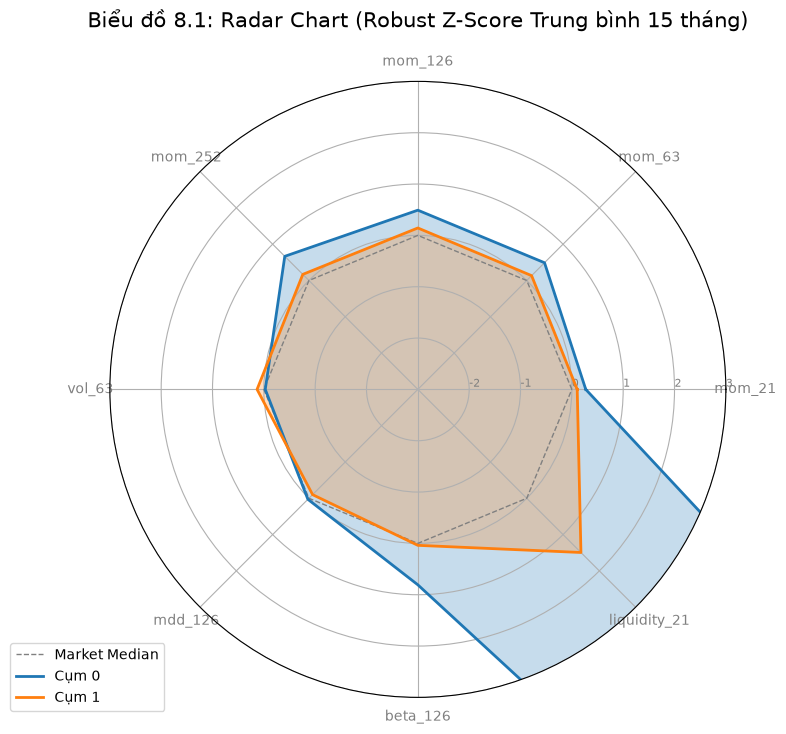

In [5]:
angles = [n / float(8) * 2 * pi for n in range(8)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
plt.xticks(angles[:-1], radar_features, color='grey', size=10)
ax.set_rlabel_position(0)
plt.yticks([-3, -2, -1, 0, 1, 2, 3], ["-3", "-2", "-1", "0", "1", "2", "3"], color="grey", size=8)
plt.ylim(-3, 3)

ax.plot(angles, [0]*9, linewidth=1, linestyle='--', color='gray', label='Market Median')
ax.plot(angles, val0, linewidth=2, linestyle='solid', label="Cụm 0")
ax.fill(angles, val0, alpha=0.25)

ax.plot(angles, val1, linewidth=2, linestyle='solid', label="Cụm 1")
ax.fill(angles, val1, alpha=0.25)

plt.title('Biểu đồ 8.1: Radar Chart (Robust Z-Score Trung bình 15 tháng)', size=15, pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

plt.savefig(f'{out_dir}/radar_chart.png', dpi=300)
plt.show()


## 5. Biểu đồ 8.2: Heatmap Đặc trưng

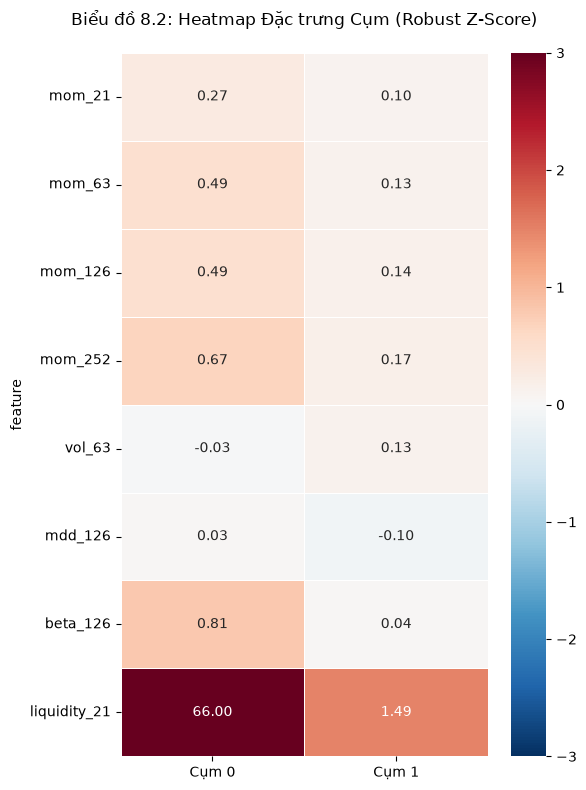

In [6]:
heatmap_data = df_scaled[radar_features].T
heatmap_data.columns = ['Cụm 0', 'Cụm 1']

plt.figure(figsize=(6, 8))
sns.heatmap(heatmap_data, annot=True, cmap='RdBu_r', center=0, 
            vmin=-3, vmax=3, fmt=".2f", linewidths=.5)
plt.title('Biểu đồ 8.2: Heatmap Đặc trưng Cụm (Robust Z-Score)', pad=20)
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(f'{out_dir}/heatmap.png', dpi=300)
plt.show()
